In [1]:
# library packages
import os
import csv
import glob
import math
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
# input folder 
file_path = "D:/data/Analysis Data/python_analysis/input"
data_files = os.listdir(file_path)

# output folder
folder_save = "D:/data/Analysis Data/python_analysis/output"

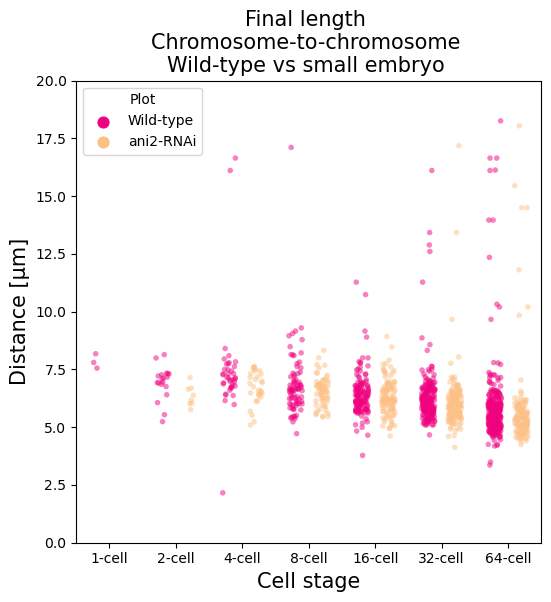

In [4]:
files = []
with os.scandir(file_path) as data_files:
    for i in data_files:
        # read out the files from the folder
        df = pd.read_csv(i, index_col=None)
        files.append(df)

# assign variables to the items in the list
df1 = files[0]
df2 = files[1]

# group the dataframes as 2 groups
'''The dataframe must annotated corrected to avoid mis-representation of data'''
# df1['Plot'] = 'mean'
# df2['Plot'] = 'Experiment'

df1['Plot'] = 'Wild-type'
df2['Plot'] = 'ani2-RNAi'

# merge the 2 dataframes from the list
new_df = pd.concat([df1, df2])

# make a plot for the first cell stage adding the features needed
fig, ax = plt.subplots(figsize=(6,6))

# choose the custom color palette 
# palette = ['#006600', '#330066', '#FFAA33', '#3333FF', '#00FFFF', '#b84873']
# palette = ['#CC2EA5', '#006600', '#330066', '#FFAA33', '#3333FF', '#00FFFF', '#b84873']
# sns.set_palette(palette, n_colors=6, color_codes=True)

# plot the primary data
ax1 = sns.stripplot(x='variable', y='value', hue='Plot', 
                    data=pd.melt(new_df, id_vars=['Plot']), 
                    size=4, 
                    palette='Accent_r', 
                    jitter=0.2, 
                    dodge=6, 
                    alpha=0.5, ax=ax)

# Make the boxplot on the plotted data
# ax2 = sns.boxplot(x='variable', y='value', hue='Plot', 
#                   data=pd.melt(new_df, id_vars=['Plot']), 
#                   palette='bone_r', 
#                   dodge=10, ax=ax)
        
# plot features
'''wild-type vs ani2-RNAi'''
ax1.axes.set_title('Final length \nChromosome-to-chromosome \nWild-type vs small embryo ', fontsize=15)

# axis label
ax1.set_xlabel("Cell stage",fontsize=15)
ax1.set_ylabel("Distance [μm]",fontsize=15)
ax1.set(ylim=(0, 20))

# save to different folder
'''wild-type vs ani2-RNAi'''
# ax2.figure.savefig(os.path.join(folder_save, 'Wild-RNAi_COMPARE_Final_C_C.png'), dpi=300) 
# ax2.figure.savefig(os.path.join(folder_save, 'Wild-RNAi_COMPARE_Final_C_C.svg'))

ax1.figure.savefig(os.path.join(folder_save, 'Wild-RNAi_COMPARE_Final_C_C.png'), dpi=300) 
ax1.figure.savefig(os.path.join(folder_save, 'Wild-RNAi_COMPARE_Final_C_C.svg'))

       
      
